In [1]:
import os
os.chdir("../")

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from corrosion1d.configs import Configs
configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
    "mathtext.fontset": "dejavusans",
})


save_fig_dir = "./figures/"

## 绘制各种曲线图

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


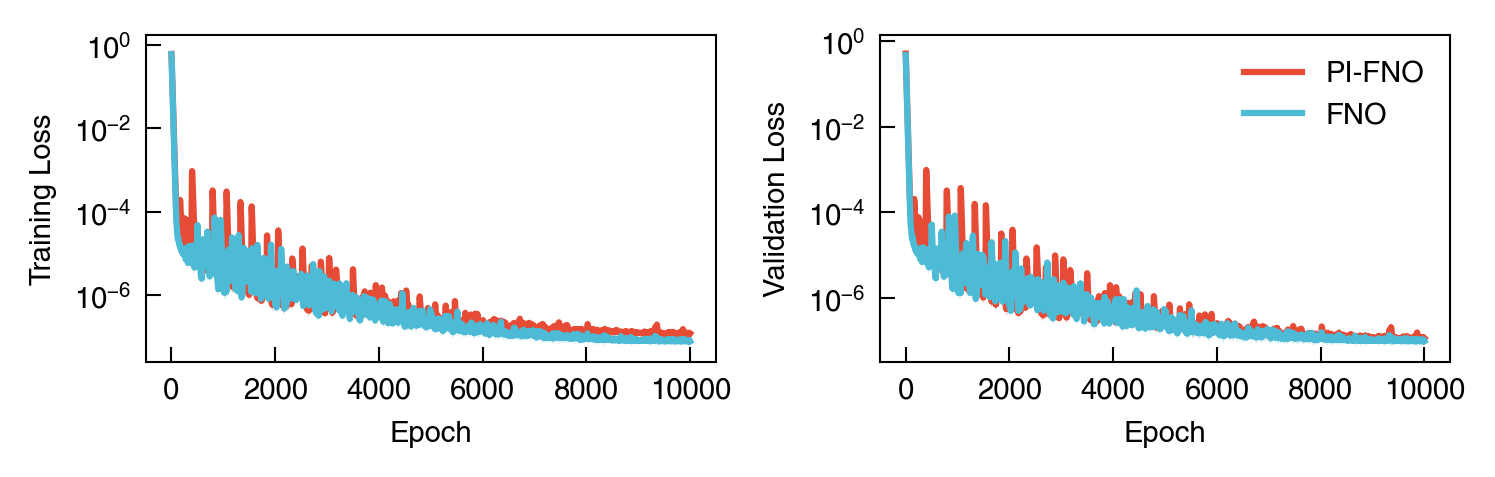

In [7]:
# read csv loss
import pandas as pd
root = "/root/autodl-tmp/runs/corrosion1d"
save_dir_pino = f"{root}/FNO-PI/"
save_dir_fno = f"{root}/FNO/"
save_dir_unet = f"{root}/UNET/"
save_dir_piunet = f"{root}/UNET-PI/"
# save_dir_fcn = "./corrosion1d/runs/FCN/"
# loss_df_fno = pd.read_csv(os.path.join(save_dir_fno, "logs.csv"))
# loss_df_pino = pd.read_csv(os.path.join(save_dir_pino, "logs.csv"))
# test_df_fno = pd.read_csv(os.path.join(save_dir_fno, "test_logs.csv"))

dirs = [
    (save_dir_pino, "PI-FNO"),
    (save_dir_fno, "FNO"),
    # (save_dir_unet, "UNet"),
    # (save_dir_piunet, "PI-UNet"),
]
import numpy as np
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.3 * np.abs(ewm_mean))
    
    return ewm_mean, ci


fig, axes = plt.subplots(1, 2, figsize=(5.0, 1.6),)
for idx, (dir_path, model_name) in enumerate(dirs):
    loss_df = pd.read_csv(os.path.join(dir_path, "logs.csv"))
    
    ax = axes[0]
    # ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["TrainLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    
    ax = axes[1]
    # ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["ValidLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion1d_training_validation_loss.pdf"), dpi=300, bbox_inches='tight', pad_inches=0.0)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


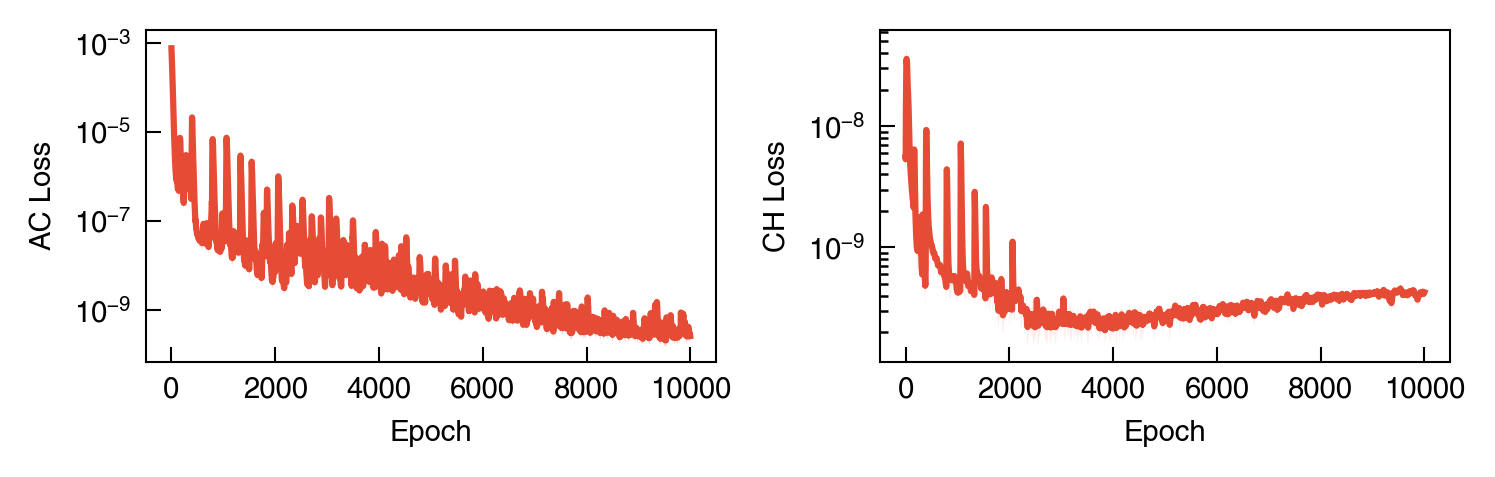

In [14]:
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.3 * np.abs(ewm_mean))
    
    return ewm_mean, ci

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 1.6))
pino_loss_df = pd.read_csv(os.path.join(save_dir_pino, "logs.csv"))

ax = axes[0]
mean, ci = smooth_and_ci_ewma(pino_loss_df["ACLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("AC Loss")

ax = axes[1]
mean, ci = smooth_and_ci_ewma(pino_loss_df["CHLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.1)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("CH Loss")

fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion1d_ac_ch_loss.pdf"), dpi=300, bbox_inches='tight', pad_inches=0.0)

Text(0, 0.5, 'Test MSE Loss')

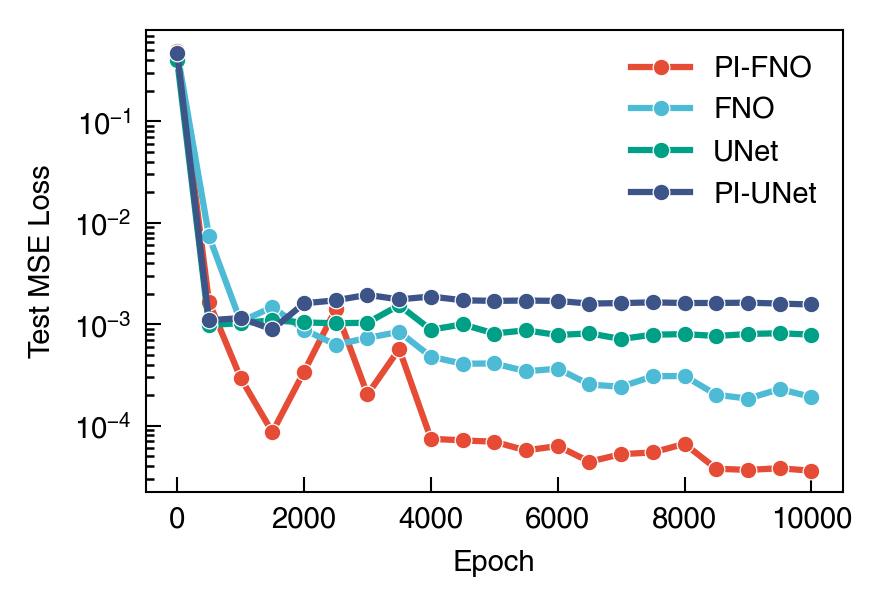

In [5]:
# test_df_fno = pd.read_csv(os.path.join(save_dir_fno, "test_logs.csv"))
# test_df_pino = pd.read_csv(os.path.join(save_dir_pino, "test_logs.csv"))

fig, ax = plt.subplots(1, 1, figsize=(3.0, 2.0))
# ax.plot(test_df_fno["Epoch"], test_df_fno["TestMSE"], label="FNO", marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
# ax.plot(test_df_pino["Epoch"], test_df_pino["TestMSE"], label="PINO", marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)

for dir_path, model_name in dirs:
    test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
    ax.plot(test_df["Epoch"], test_df["TestMSE"], label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
    

ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test MSE Loss")
# ax_in = ax.inset_axes([0.2, 0.2, 0.47, 0.47], xlim=(8000, 10000), ylim=(1e-5, 1e-3), yscale="log")
# for dir_path, model_name in dirs:
#     test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
#     ax_in.plot(test_df["Epoch"], test_df["TestMSE"], label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)

    

# fig.tight_layout()
# print("Final FNO Test MSE:", test_df_fno["TestMSE"].values[-1])
# print("Final PINO Test MSE:", test_df_pino["TestMSE"].values[-1])

(6, 100, 2, 101)
Mean error shape: (100,)
(6, 100, 2, 101)
Mean error shape: (100,)
(6, 100, 2, 101)
Mean error shape: (100,)
(6, 100, 2, 101)
Mean error shape: (100,)


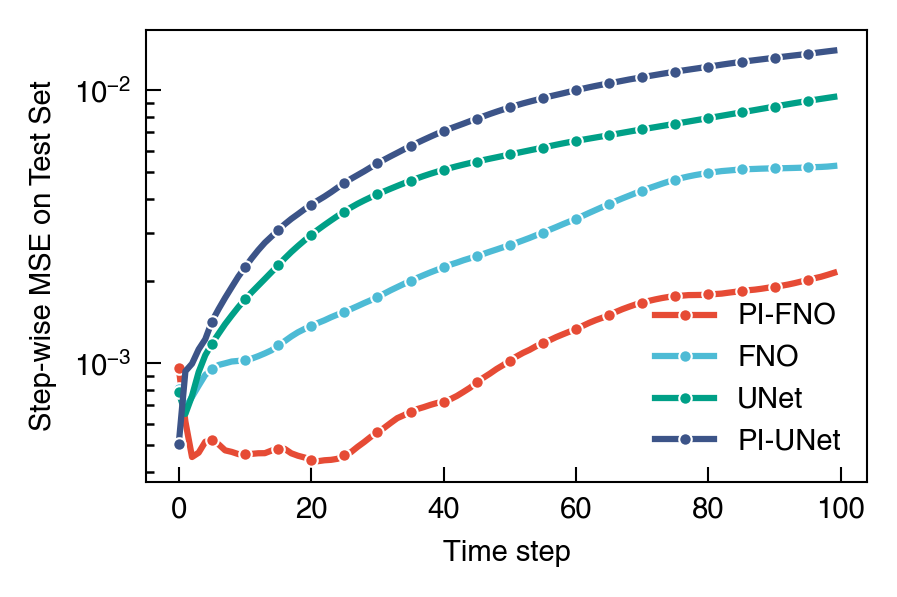

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
for dir_path, model_name in dirs:
    test_results = jnp.load(os.path.join(dir_path, "test_results.npz"))
    y_test = test_results["y_test"]
    y_test_pred = test_results["y_test_pred"]
    error = jnp.abs(y_test - y_test_pred)
    print(error.shape)
    mean_error = jnp.mean(error, axis=(0,2,3))
    print("Mean error shape:", mean_error.shape)
    ax.plot(mean_error, label=model_name, marker='o', markersize=3, 
            markeredgecolor="white", markevery=5, markeredgewidth=0.5)
# plot_mean_with_std(ax, mean_error_fno, color="C0", label="FNO")
# plot_mean_with_std(ax, mean_error_pino, color="C1", label="PINO")
ax.legend()
ax.set_ylabel("Step-wise MSE on Test Set")
ax.set_yscale("log")
ax.set_xlabel("Time step")

fig.tight_layout()

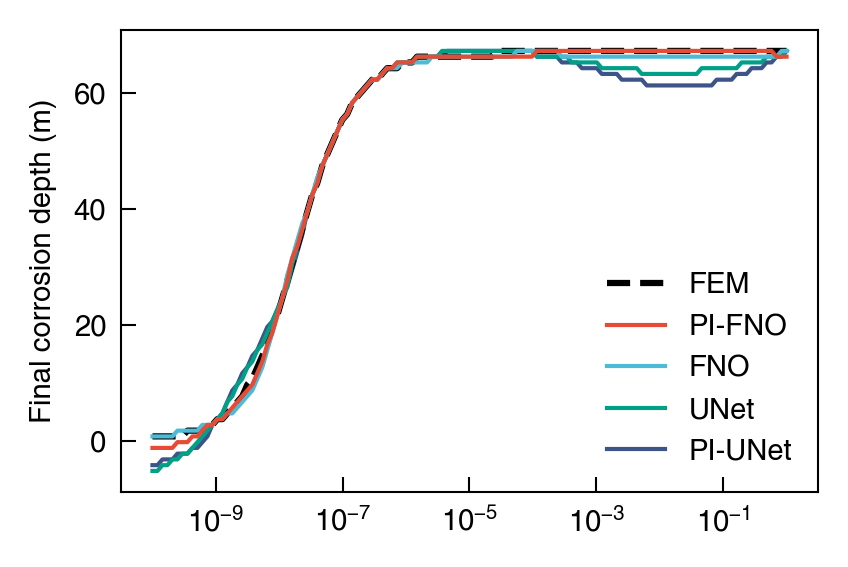

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
lps = jnp.load("/root/autodl-tmp/data/corrosion1d/final_corrosion_depth/Lp_values.npy")
final_corrosion_depths_fem = jnp.load("/root/autodl-tmp/data/corrosion1d/final_corrosion_depth/final_corrosion_depth.npy") * 1e6  # in microns
ax.plot(lps, final_corrosion_depths_fem, label="FEM", color="black", linestyle="--",)
for idx, (dir_path, model_name) in enumerate(dirs):
    final_corrosion_depth = jnp.load(os.path.join(dir_path, "corrosion_depths.npz"))["corrosion_depths"]
    ax.plot(lps, final_corrosion_depth, label=model_name, lw=1, zorder=(len(dirs)-idx))
ax.set_xscale("log")
ax.set_ylabel("Final corrosion depth (m)")
ax.legend()


## 加载多种模型对比

In [8]:
# from model import model1d
from corrosion1d.model1d import get_model1d

model_kwargs = {
   'modes': configs.modes,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
   'inception': configs.inception,
}

# Add VAE-specific parameters if needed
if configs.model_type == 'vae':
   model_kwargs.update({
      'latent_dim': configs.latent_dim,
      'output_size': configs.output_size,
   })

model_skeleton = get_model1d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)
# model_skeleton = get_model1d(configs, jax.random.PRNGKey(0))

weight_pino = os.path.join(save_dir_pino, f"epoch_{configs.epochs - 1}.eqx")
model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)
weight_fno = os.path.join(save_dir_fno, f"epoch_{configs.epochs - 1}.eqx")
model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)

In [9]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_1d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_1d_complete.npz"))["times"]
dt = times[1] - times[0]
Xs.shape, Ys.shape

((175, 5, 101), (175, 2, 101))

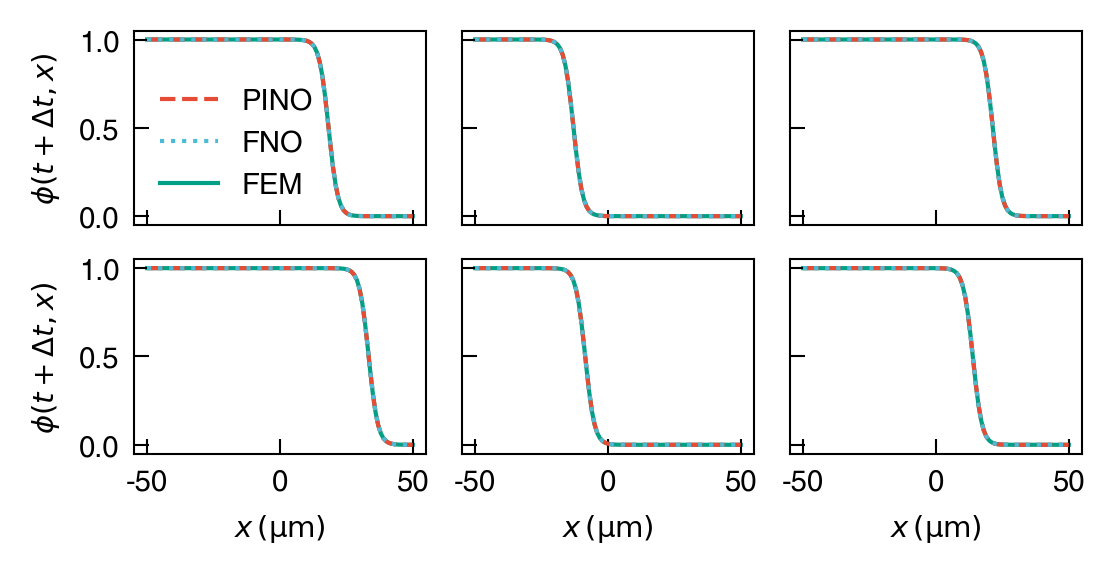

In [10]:
num_examples = 6
import numpy as np
np.random.seed(42)
random_indices = np.random.choice(Xs.shape[0], size=num_examples, replace=False,)
fig, axes = plt.subplots(2, 3, figsize=(3.6, 1.8), constrained_layout=True, sharex=True, sharey=True)
xs_example = Xs[random_indices]
ys_example = Ys[random_indices]
y_pred_pino = jax.vmap(model_pino)(xs_example)
y_pred_fno = jax.vmap(model_fno)(xs_example)



axes = axes.flatten()
for i, idx in enumerate(random_indices):
    ax = axes[i]
    # ax.plot(meshes, xs_example[i, 0, :], label="Input", color="green")
    ax.plot(meshes*configs.Lc, y_pred_pino[i, 0, :], label="PINO", lw=1,
            color="C0", linestyle="dashed")
    ax.plot(meshes*configs.Lc, y_pred_fno[i, 0, :], label="FNO", lw=1,
            color="C1", linestyle="dotted")
    ax.plot(meshes*configs.Lc, ys_example[i, 0, :], label="FEM", lw=1,
            color="C2", zorder=-1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*1e6:.0f}"))
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
    if i == 0:
        ax.legend(loc="lower left")
    if i // 3 == 1:
        ax.set_xlabel(r"$x \, \mathrm{(\mu m)}$")
    if i % 3 == 0:
        ax.set_ylabel(r"$\phi(t+\Delta t,x)$")
# fig.savefig(os.path.join(save_fig_dir, "corrosion1d_valid_one_step_pred.pdf"), dpi=450,
#             bbox_inches='tight', pad_inches=0.0)

In [11]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions.npy"))[:, :, :, ::-1]
test_lp_values = jnp.load(os.path.join(configs.test_data_dir, "Lp_values.npy")).reshape(-1, 1)
test_meshes = jnp.load(os.path.join(configs.test_data_dir, "mesh_points.npy")).reshape(-1)[::-1]
test_times = jnp.load(os.path.join(configs.test_data_dir, "times.npy"))
test_lp_values = configs.Lpc(test_lp_values)
test_times = test_times / configs.Tc
test_meshes = test_meshes / configs.Lc
dt = test_times[1] - test_times[0]


In [12]:
x_test = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]
auto_reg_fn = partial(
    model_pino.auto_reg,
    meshes=test_meshes,
    dt=jnp.array(dt),
    steps=test_times.shape[0]-1,
)
y_test_pred = jax.vmap(auto_reg_fn,
                       in_axes=(0, 0)
                       )(x_test, test_lp_values)

In [13]:
y_test_pred.shape

(6, 100, 2, 101)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Total relative L2 error on test set: 0.005926666


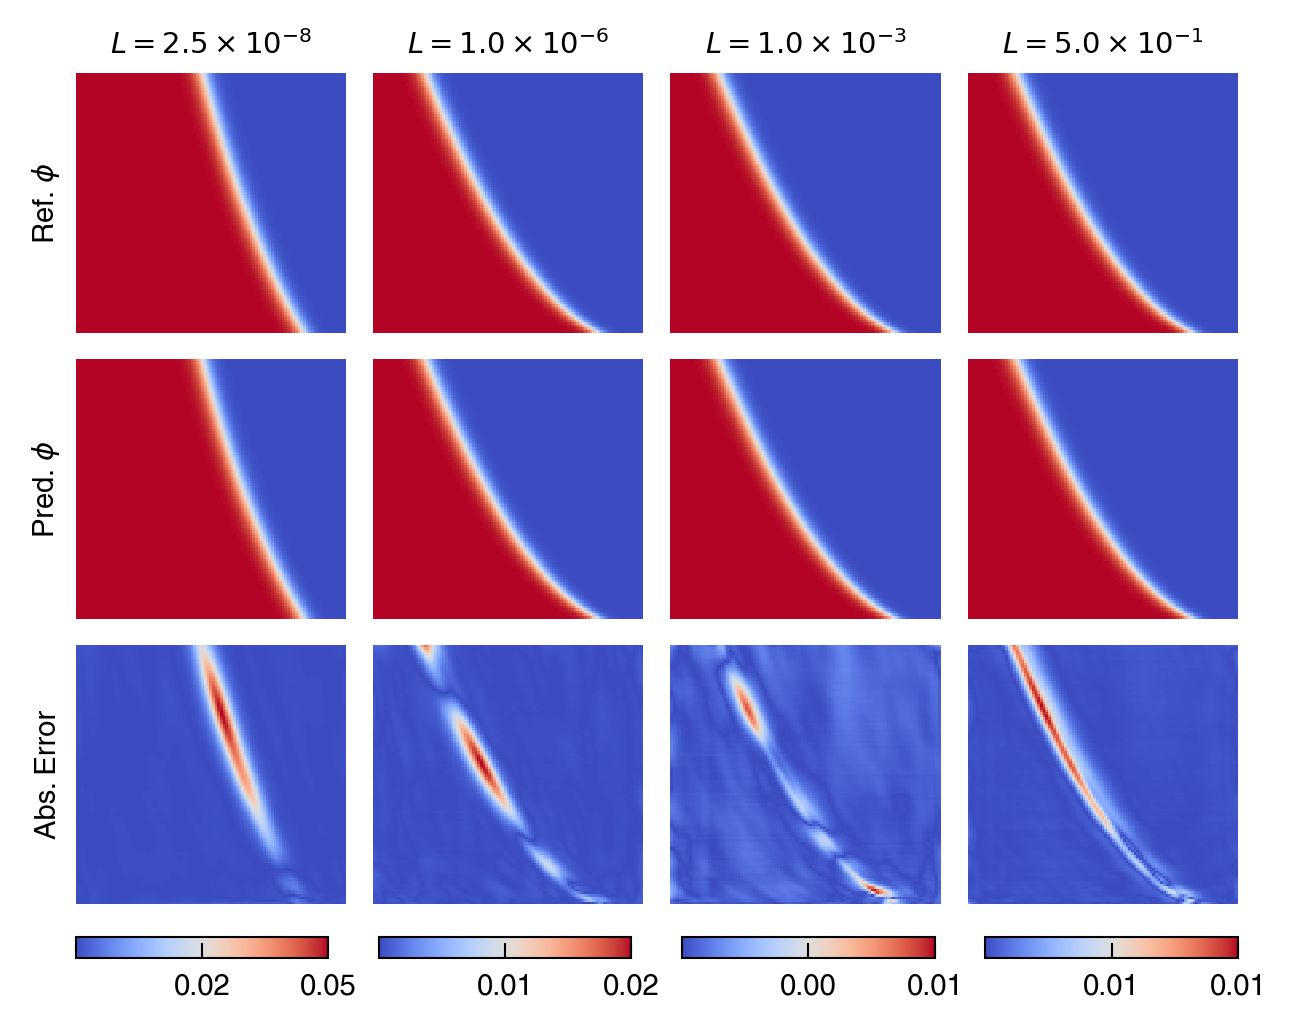

In [14]:
def num_to_latex(num, precision=2):
    mantissa, exponent = f"{num:.{precision}e}".split("e")
    exponent = int(exponent)
    return f"{mantissa}\\times 10^{{{exponent}}}"

# rm the 0th and 2nd sample
test_indices = jnp.array([1, 3, 4, 5])
y_test = y_test[test_indices]
y_test_pred = y_test_pred[test_indices]
test_lp_values = test_lp_values[test_indices]
fig, axes = plt.subplots(3, 4, figsize=(5, 3.6),)
meshes_denorm = test_meshes * configs.Lc * 1e6
times_denorm = test_times[1:] * configs.Tc

for i in range(4):
    lp_denorm = configs.Lp_from_Lpc(test_lp_values[i,0])
    ax = axes[0, i]
    ax.set_axis_off()
    sol = y_test_pred[i, :, 0, :]
    truth = y_test[i, :, 0, :]

    ax.pcolormesh(meshes_denorm, times_denorm,
                  truth, shading="auto",rasterized=True,
                  cmap="coolwarm", vmin=0, vmax=1)
    if i == 0:
        ax.set_ylabel("t (s)")
        ax.text(-0.05, 0.5, r"Ref. $\phi$", va='center', ha="right",
                rotation='vertical', 
                transform=ax.transAxes,)
    ax.text(0.5, 1.05, fr"$L={num_to_latex(lp_denorm, precision=1)}$",
            ha='center', va='bottom',
            transform=ax.transAxes,)
    
    ax = axes[1, i]
    ax.set_axis_off()
    sol = y_test_pred[i, :, 0, :]
    truth = y_test[i, :, 0, :]

    ax.pcolormesh(meshes_denorm, times_denorm, sol, shading="auto",
                  cmap="coolwarm", vmin=0, vmax=1, rasterized=True)
    
    # ax.set_title(f"Lp={lp_denorm:.2e}")

    if i == 0:
        ax.set_ylabel("t (s)")
        ax.text(-0.05, 0.5, r"Pred. $\phi$", va='center', ha="right",
                rotation='vertical', 
                transform=ax.transAxes,)
        
         
    ax = axes[2, i]
    ax.set_axis_off()
    err_bar = ax.pcolormesh(meshes_denorm, times_denorm,
                  jnp.abs(sol - truth), shading="auto",rasterized=True,
                  cmap="coolwarm",)
    # L2_err = jnp.linalg.norm(sol - truth) / jnp.linalg.norm(truth)
    # convert l2 to sci-notation and latex for: e.g. 1.0\times 10{-2}

    # l2_latex = f"{l2_mantissa}\\times 10^{{{l2_exponent}}}"

    # ax.set_title(f"$L_2={l2_latex}$")
    # ax.text(0., 0.0, f"$L_2={l2_latex}$", ha='left', va='bottom',
    #         transform=ax.transAxes,)
    ax.set_xlabel("x (µm)")
    if i == 0:
        ax.set_ylabel("t (s)")
        ax.text(-0.05, 0.5, "Abs. Error", 
                va='center', ha="right",
                rotation='vertical', 
                transform=ax.transAxes,)
    # add a colorbar to the last row
    # fig.colorbar(err_bar, ax=axes[2, i], orientation='horizontal', fraction=0.1, pad=0.1)
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    fig.colorbar(err_bar, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(-1e-8, jnp.max(jnp.abs(sol - truth)), num=3), )

fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.savefig(os.path.join(save_fig_dir, "corrosion1d_test_sol.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)
# total mse
totl_l2 = jnp.linalg.norm(y_test_pred - y_test) / jnp.linalg.norm(y_test)
print("Total relative L2 error on test set:", totl_l2)


In [15]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions.npy"))[:, :, :, ::-1]
test_lp_values = jnp.load(os.path.join(configs.test_data_dir, "Lp_values.npy")).reshape(-1, 1)
test_meshes = jnp.load(os.path.join(configs.test_data_dir, "mesh_points.npy")).reshape(-1)[::-1]
test_times = jnp.load(os.path.join(configs.test_data_dir, "times.npy"))
test_lp_values = configs.Lpc(test_lp_values)
test_times = test_times / configs.Tc
test_meshes = test_meshes / configs.Lc
dt = test_times[1] - test_times[0]
x_test = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]

In [16]:


auto_reg_fn_pino = partial(
    model_pino.auto_reg,
    meshes=test_meshes,
    dt=jnp.array(dt),
    steps=test_times.shape[0]-1,
)
y_test_pred_pino = jax.vmap(auto_reg_fn_pino,
                       in_axes=(0, 0)
                       )(x_test, test_lp_values)

auto_reg_fn_fno = partial(
    model_fno.auto_reg,
    meshes=test_meshes,
    dt=jnp.array(dt),
    steps=test_times.shape[0]-1,
)
y_test_pred_fno = jax.vmap(auto_reg_fn_fno,
                       in_axes=(0, 0)
                       )(x_test, test_lp_values)


In [17]:
y_test_pred_pino.shape, y_test_pred_fno.shape, y_test.shape

((6, 100, 2, 101), (6, 100, 2, 101), (6, 100, 2, 101))

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


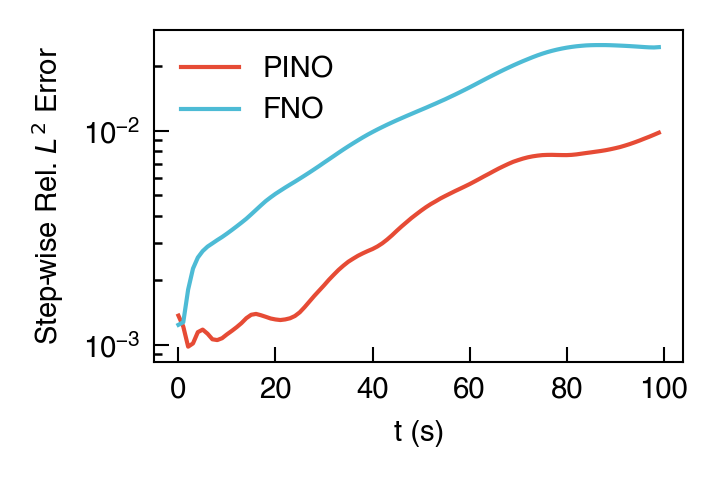

In [18]:
step_wise_l2_pino = jnp.linalg.norm(y_test_pred_pino - y_test, axis=(3)) / jnp.linalg.norm(y_test, axis=(3))
step_wise_l2_fno = jnp.linalg.norm(y_test_pred_fno - y_test, axis=(3)) / jnp.linalg.norm(y_test, axis=(3))
step_wise_l2_pino = jnp.mean(step_wise_l2_pino, axis=(0,2)) # avg over samples and channels
step_wise_l2_fno = jnp.mean(step_wise_l2_fno, axis=(0,2)) # avg over samples and channels
fig, ax = plt.subplots(1, 1, figsize=(2.4, 1.6))
ax.plot(step_wise_l2_pino, label="PINO", lw=1)
ax.plot(step_wise_l2_fno, label="FNO", lw=1)
ax.set_yscale("log")
ax.set_xlabel(r"t (s)")
ax.set_ylabel("Step-wise Rel. $L^2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion1d_stepwise_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

In [19]:
epochs = jnp.arange(0, configs.epochs, configs.test_every)

l2_pino_list = []
l2_fno_list = []

def compute_l2(model, x_test, y_test, test_meshes, test_lp_values, dt, test_times):
    auto_reg_fn = partial(
        model.auto_reg,
        meshes=test_meshes,
        dt=jnp.array(dt),
        steps=test_times.shape[0]-1,
    )
    y_test_pred = jax.vmap(auto_reg_fn,
                           in_axes=(0, 0)
                           )(x_test, test_lp_values)

    # shape [sample, T, channel, spatial]
    l2 = jnp.linalg.norm(y_test_pred - y_test, axis=(1,3)) / jnp.linalg.norm(y_test, axis=(1,3))
    l2 = jnp.mean(l2)  # avg over samples
    return l2
    
for epoch in epochs:
    weight_pino = os.path.join(save_dir_pino, f"epoch_{epoch}.eqx")
    model_pino = eqx.tree_deserialise_leaves(weight_pino, model_skeleton)
    l2_pino = compute_l2(model_pino, x_test, y_test, test_meshes, test_lp_values, dt, test_times)
    l2_pino_list.append(l2_pino)
    weight_fno = os.path.join(save_dir_fno, f"epoch_{epoch}.eqx")
    model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)
    l2_fno = compute_l2(model_fno, x_test, y_test, test_meshes, test_lp_values, dt, test_times)
    l2_fno_list.append(l2_fno)


2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


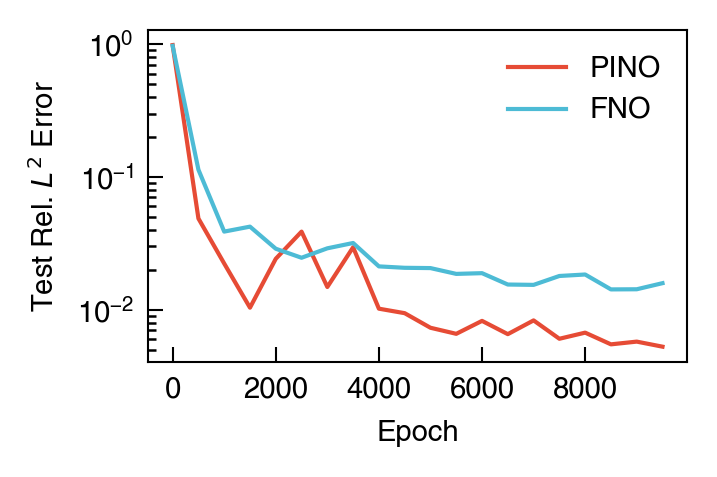

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(2.4, 1.6))
ax.plot(epochs, l2_pino_list, label="PINO", lw=1)
ax.plot(epochs, l2_fno_list, label="FNO", lw=1)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Rel. $L^2$ Error")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion1d_test_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

In [21]:
print("Final PINO L2:", l2_pino_list[-1])
print("Final FNO L2:", l2_fno_list[-1])

Final PINO L2: 0.0052668313
Final FNO L2: 0.015836332


In [22]:
configs.test_data_dir

'/root/autodl-tmp/data/corrosion1d/test/'

test super-resolution

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


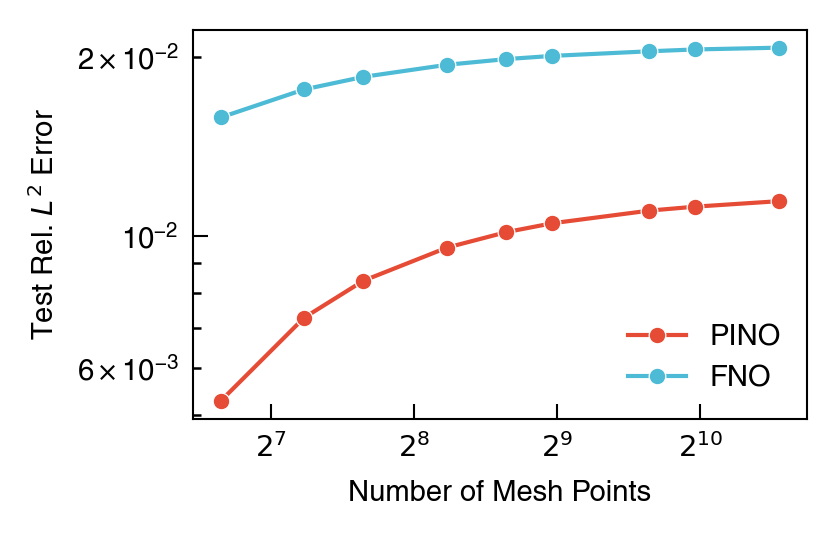

In [26]:
# test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions.npy"))[:, :, :, ::-1]
root_dir = configs.test_data_dir

data_paths = {
    100: root_dir + "mesh_100/solutions.npy",
    150: root_dir + "mesh_150/solutions.npy",
    200: root_dir + "mesh_200/solutions.npy",
    300: root_dir + "mesh_300/solutions.npy",
    400: root_dir + "mesh_400/solutions.npy",
    500: root_dir + "mesh_500/solutions.npy",
    800: root_dir + "mesh_800/solutions.npy",
    1000: root_dir + "mesh_1000/solutions.npy",
    1500: root_dir + "mesh_1500/solutions.npy",
}

l2_pino_list = []
l2_fno_list = []

for i, (num_mesh, path) in enumerate(data_paths.items()):
    test_solutions = jnp.load(path)[:, :, :, ::-1]
    test_lp_values = jnp.load(os.path.join(configs.test_data_dir, "Lp_values.npy")).reshape(-1, 1)
    test_meshes = jnp.load(os.path.join(configs.test_data_dir, f"mesh_{num_mesh}/mesh_points.npy")).reshape(-1)[::-1]
    test_times = jnp.load(os.path.join(configs.test_data_dir, "times.npy"))
    test_lp_values = configs.Lpc(test_lp_values)
    test_times = test_times / configs.Tc
    test_meshes = test_meshes / configs.Lc
    dt = test_times[1] - test_times[0]
    x_test = test_solutions[:, 0, :, :]
    y_test = test_solutions[:, 1:, :, :]
    
    l2_pino = compute_l2(model_pino, x_test, y_test, test_meshes, test_lp_values, dt, test_times)
    l2_pino_list.append(l2_pino)
    l2_fno = compute_l2(model_fno, x_test, y_test, test_meshes, test_lp_values, dt, test_times)
    l2_fno_list.append(l2_fno)


fig, ax = plt.subplots(1, 1, figsize=(2.8, 1.8))
num_meshes = jnp.array(list(data_paths.keys()))
ax.plot(jnp.log2(num_meshes), l2_pino_list, 
        label="PINO", lw=1, marker='o',  markersize=4, markeredgecolor="white", markeredgewidth=0.3)
ax.plot(jnp.log2(num_meshes), l2_fno_list, 
        label="FNO", lw=1, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("Number of Mesh Points")
ax.set_ylabel("Test Rel. $L^2$ Error")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"$2^{{{int(x)}}}$"))
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "corrosion1d_super_resolution_l2.pdf"), dpi=450, 
            bbox_inches='tight', pad_inches=0.0)

In [24]:
l2_pino_list

[Array(0.00526683, dtype=float32),
 Array(0.00728163, dtype=float32),
 Array(0.00840599, dtype=float32),
 Array(0.00955926, dtype=float32),
 Array(0.01015096, dtype=float32),
 Array(0.01050641, dtype=float32),
 Array(0.01103391, dtype=float32),
 Array(0.0112053, dtype=float32),
 Array(0.01144618, dtype=float32)]